# Chapter 5: Text Clustering and Topic Modeling

In [1]:
!pip  install bertopic datasets openai datamapplot bertopic

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.6/350.6 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 105.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 49.5 MB/s eta 0:00:00
  Created wheel for Pyqtree: filename=pyqtree-1.0.0-py3-none-any.whl size=6013 sha256=a1f9429f7e6f4af14b92fe9a9f0bea097f9baab9727ecefcaa3ccdccafe126a3
  Stored in directory: /root/.cache/pip/wheels/86/02/24/506ac193949f48c8bec599b613d722bd64a83063a190b3bff7
Successfully built Pyqtree
  Attempting uninstall: dask
    Found existing installation: dask 2026.1.1
    Uninstalling dask-2026.1.1:
      S

# ArXiv Articles: Computation and Language

In [2]:
# Load data from huggingface
from datasets import load_dataset
dataset = load_dataset("maartengr/arxiv_nlp")["train"]

# Extract metadata
abstracts = list(dataset["Abstracts"])
titles = list(dataset["Titles"])

README.md:   0%|          | 0.00/617 [00:00<?, ?B/s]

data.csv:   0%|          | 0.00/53.2M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

# A Common Pipeline for Text Clustering

## 1. Embedding Documents

In [3]:
from sentence_transformers import SentenceTransformer

# Create an embedding for each abstract
embedding_model = SentenceTransformer('thenlper/gte-small')
embeddings = embedding_model.encode(abstracts, show_progress_bar=True)

modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/66.7M [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1405 [00:00<?, ?it/s]

In [4]:
# Check the dimensions of the resulting embeddings
embeddings.shape

(44949, 384)

## 2. Reducing the Dimensionality of Embeddings

In [5]:
from umap import UMAP

# We reduce the input embeddings from 384 dimenions to 5 dimenions
umap_model = UMAP(
    n_components=5, min_dist=0.0, metric='cosine', random_state=42
)
reduced_embeddings = umap_model.fit_transform(embeddings)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## 3. Cluster the Reduced Embeddings

In [6]:
from hdbscan import HDBSCAN

# We fit the model and extract the clusters
hdbscan_model = HDBSCAN(
    min_cluster_size=50, metric='euclidean', cluster_selection_method='eom'
).fit(reduced_embeddings)
clusters = hdbscan_model.labels_

# How many clusters did we generate?
len(set(clusters))

159

## Inspecting the Clusters

In [7]:
import numpy as np

# Print first three documents in cluster 0
cluster = 0
for index in np.where(clusters==cluster)[0][:3]:
    print(abstracts[index][:300] + "... \n")

  This works aims to design a statistical machine translation from English text
to American Sign Language (ASL). The system is based on Moses tool with some
modifications and the results are synthesized through a 3D avatar for
interpretation. First, we translate the input text to gloss, a written fo... 

  Researches on signed languages still strongly dissociate lin- guistic issues
related on phonological and phonetic aspects, and gesture studies for
recognition and synthesis purposes. This paper focuses on the imbrication of
motion and meaning for the analysis, synthesis and evaluation of sign lang... 

  Modern computational linguistic software cannot produce important aspects of
sign language translation. Using some researches we deduce that the majority of
automatic sign language translation systems ignore many aspects when they
generate animation; therefore the interpretation lost the truth inf... 



In [8]:
import pandas as pd

# Reduce 384-dimensional embeddings to 2 dimensions for easier visualization
reduced_embeddings = UMAP(
    n_components=2, min_dist=0.0, metric='cosine', random_state=42
).fit_transform(embeddings)

# Create dataframe
df = pd.DataFrame(reduced_embeddings, columns=["x", "y"])
df["title"] = titles
df["cluster"] = [str(c) for c in clusters]

# Select outliers and non-outliers (clusters)
clusters_df = df.loc[df.cluster != "-1", :]
outliers_df = df.loc[df.cluster == "-1", :]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(np.float64(-9.041299676895141),
 np.float64(11.615294313430786),
 np.float64(-7.6163016080856325),
 np.float64(11.084579062461852))

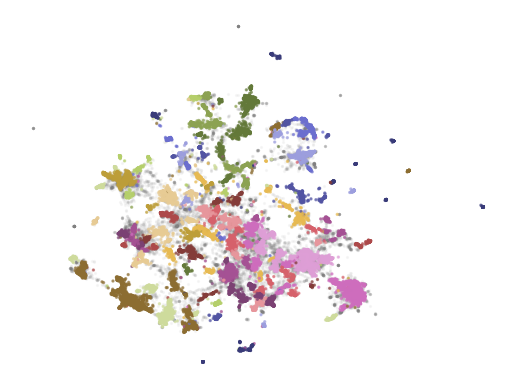

In [9]:
import matplotlib.pyplot as plt

# Plot outliers and non-outliers seperately
plt.scatter(outliers_df.x, outliers_df.y, alpha=0.05, s=2, c="grey")
plt.scatter(
    clusters_df.x, clusters_df.y, c=clusters_df.cluster.astype(int),
    alpha=0.6, s=2, cmap='tab20b'
)
plt.axis('off')
# plt.savefig("matplotlib.png", dpi=300)  # Uncomment to save the graph as a .png

# From Text Clustering to Topic Modeling

## BERTopic: A Modular Topic Modeling Framework

In [10]:
from bertopic import BERTopic

# Train our model with our previously defined models
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True
).fit(abstracts, embeddings)

2026-08-15 11:53:31,068 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-15 11:54:18,155 - BERTopic - Dimensionality - Completed ✓
2026-08-15 11:54:18,157 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-15 11:54:19,686 - BERTopic - Cluster - Completed ✓
2026-08-15 11:54:19,701 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-15 11:54:23,579 - BERTopic - Representation - Completed ✓


In [11]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,15538,-1_the_of_and_to,"[the, of, and, to, in, we, for, that, language...",[ Learning to construct text representations ...
1,0,1587,0_speech_asr_recognition_end,"[speech, asr, recognition, end, acoustic, wer,...",[ Recent advances in text-to-speech (TTS) led...
2,1,1479,1_medical_clinical_biomedical_patient,"[medical, clinical, biomedical, patient, healt...",[ A common practice in the medical industry i...
3,2,1069,2_translation_nmt_machine_bleu,"[translation, nmt, machine, bleu, neural, engl...",[ The quality of machine translation is rapid...
4,3,837,3_hate_offensive_speech_detection,"[hate, offensive, speech, detection, toxic, so...",[ With growing role of social media in shapin...
...,...,...,...,...,...
154,153,54,153_counseling_mental_therapy_health,"[counseling, mental, therapy, health, psychoth...",[ Mental health care poses an increasingly se...
155,154,52,154_backdoor_attacks_attack_triggers,"[backdoor, attacks, attack, triggers, poisoned...",[ Deep neural networks (DNNs) and natural lan...
156,155,52,155_gans_gan_adversarial_generation,"[gans, gan, adversarial, generation, generativ...",[ Text generation is of particular interest i...
157,156,51,156_temporal_events_event_timeml,"[temporal, events, event, timeml, relations, r...",[ Temporal relation extraction models have th...


In [12]:
topic_model.get_topic(0)

[('speech', np.float64(0.028533409123771385)),
 ('asr', np.float64(0.019138833922540077)),
 ('recognition', np.float64(0.013909133719155576)),
 ('end', np.float64(0.010621429434304063)),
 ('acoustic', np.float64(0.010460956236705904)),
 ('wer', np.float64(0.007447408821110592)),
 ('speaker', np.float64(0.0073356609562662605)),
 ('error', np.float64(0.006711808807312123)),
 ('ctc', np.float64(0.006453412080461576)),
 ('training', np.float64(0.0064466744613668105))]

In [13]:
topic_model.find_topics("topic modeling")

([25, -1, 1, 46, 39],
 [np.float64(0.9544818776383237),
  np.float64(0.9115890889009828),
  np.float64(0.9082214517245877),
  np.float64(0.9073075009451413),
  np.float64(0.9049991993776167)])

In [14]:
topic_model.get_topic(22)

[('attention', np.float64(0.03338783167162634)),
 ('transformer', np.float64(0.026044416462860417)),
 ('transformers', np.float64(0.01629727171337091)),
 ('self', np.float64(0.011231870914183944)),
 ('heads', np.float64(0.00973677067231886)),
 ('head', np.float64(0.009331423482875849)),
 ('memory', np.float64(0.008790051066581806)),
 ('long', np.float64(0.008146386089631596)),
 ('tokens', np.float64(0.007622467768719387)),
 ('layer', np.float64(0.007567990795637122))]

In [15]:
topic_model.topics_[titles.index('BERTopic: Neural topic modeling with a class-based TF-IDF procedure')]

25

### Visualisation

In [16]:
# Visualize topics and documents
fig = topic_model.visualize_documents(
    titles,
    reduced_embeddings=reduced_embeddings,
    width=1200,
    hide_annotations=True
)

# Update fonts of legend for easier visualization
fig.update_layout(font=dict(size=16))


In [17]:
# Visualize barchart with ranked keywords
topic_model.visualize_barchart()

In [18]:
# Visualize relationships between topics
topic_model.visualize_heatmap(n_clusters=30)

In [19]:
# Visualize the potential hierarchical structure of topics
topic_model.visualize_hierarchy()

## Adding a special lego block

In [20]:
# Save original representations
from copy import deepcopy
original_topics = deepcopy(topic_model.topic_representations_)

In [21]:
def topic_differences(model, original_topics, nr_topics=5):
    """Show the differences in topic representations between two models """
    df = pd.DataFrame(columns=["Topic", "Original", "Updated"])
    for topic in range(nr_topics):

        # Extract top 5 words per topic per model
        og_words = " | ".join(list(zip(*original_topics[topic]))[0][:5])
        new_words = " | ".join(list(zip(*model.get_topic(topic)))[0][:5])
        df.loc[len(df)] = [topic, og_words, new_words]

    return df

### KeyBERTInspired

In [22]:
from bertopic.representation import KeyBERTInspired

# Update our topic representations using KeyBERTInspired
representation_model = KeyBERTInspired()
topic_model.update_topics(abstracts, representation_model=representation_model)

# Show topic differences
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,speech | asr | recognition | end | acoustic,speech | language | phonetic | translation | t...
1,1,medical | clinical | biomedical | patient | he...,clinical | nlp | ehr | medicine | corpus
2,2,translation | nmt | machine | bleu | neural,translation | translations | multilingual | tr...
3,3,hate | offensive | speech | detection | toxic,hate | hateful | language | offensive | cyberb...
4,4,relation | extraction | re | relations | entity,relation | relations | relational | sentences ...


### Maximal Marginal Relevance

In [23]:
from bertopic.representation import MaximalMarginalRelevance

# Update our topic representations to MaximalMarginalRelevance
representation_model = MaximalMarginalRelevance(diversity=0.5)
topic_model.update_topics(abstracts, representation_model=representation_model)

# Show topic differences
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,speech | asr | recognition | end | acoustic,asr | error | ctc | training | audio
1,1,medical | clinical | biomedical | patient | he...,clinical | biomedical | patient | healthcare |...
2,2,translation | nmt | machine | bleu | neural,translation | nmt | bleu | neural | parallel
3,3,hate | offensive | speech | detection | toxic,hate | toxic | abusive | comments | platforms
4,4,relation | extraction | re | relations | entity,extraction | relations | entity | distant | se...


## Text Generation

### Flan-T5

In [24]:
from transformers import pipeline
from bertopic.representation import TextGeneration

prompt = """I have a topic that contains the following documents:
[DOCUMENTS]

The topic is described by the following keywords: '[KEYWORDS]'.

Based on the documents and keywords, what is this topic about?"""

# Update our topic representations using Flan-T5
generator = pipeline('text-generation', model='google/flan-t5-small')
representation_model = TextGeneration(
    generator, prompt=prompt, doc_length=50, tokenizer="whitespace"
)
topic_model.update_topics(abstracts, representation_model=representation_model)

# Show topic differences
topic_differences(topic_model, original_topics)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

...

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLlamaForCausalLM', 'DogeForCausalLM', 'Dots1ForCausalLM', 'ElectraForCausalLM', 'Emu3ForCausalLM', 'ErnieForCausalLM', 'Ernie4_5ForCausalLM', 'Ernie4_5_MoeForCausalLM', 'Exaone4ForCausalLM', 'FalconForCausalLM', 'FalconH1ForCausalLM', 'FalconMambaForCausa

KeyboardInterrupt: 

### OpenAI

In [ ]:
# import openai
# from bertopic.representation import OpenAI

# prompt = """
# I have a topic that contains the following documents:
# [DOCUMENTS]

# The topic is described by the following keywords: [KEYWORDS]

# Based on the information above, extract a short topic label in the following format:
# topic: <short topic label>
# """

# # Update our topic representations using GPT-3.5
# client = openai.OpenAI(api_key="YOUR_KEY_HERE")
# representation_model = OpenAI(
#     client, model="gpt-3.5-turbo", exponential_backoff=True, chat=True, prompt=prompt
# )
# topic_model.update_topics(abstracts, representation_model=representation_model)

# # Show topic differences
# topic_differences(topic_model, original_topics)

In [ ]:
# # Visualize topics and documents
# fig = topic_model.visualize_document_datamap(
#     titles,
#     topics=list(range(20)),
#     reduced_embeddings=reduced_embeddings,
#     width=1200,
#     label_font_size=11,
#     label_wrap_width=20,
#     use_medoids=True,
# )
# plt.savefig("datamapplot.png", dpi=300)

## Bonus

In [25]:
topic_model.update_topics(abstracts, top_n_words=500)

2026-08-15 11:56:43,916 - BERTopic - WARNING: Note that extracting more than 100 words from a sparse can slow down computation quite a bit.


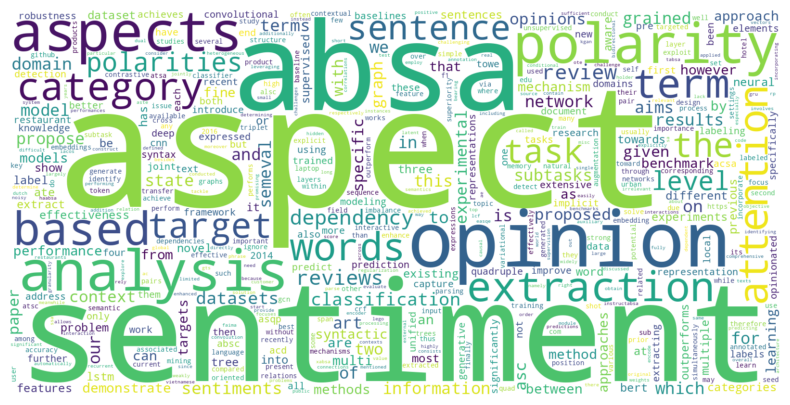

In [26]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def create_wordcloud(model, topic):
    plt.figure(figsize=(10,5))
    text = {word: value for word, value in model.get_topic(topic)}
    wc = WordCloud(background_color="white", max_words=1000, width=1600, height=800)
    wc.generate_from_frequencies(text)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()

# Show wordcloud
create_wordcloud(topic_model, topic=17)